# Smart Energy AI

## Household Appliance Energy Consumption Prediction

This notebook predicts household **Appliances** energy consumption (in Wh) using
machine learning, based on indoor conditions, outdoor weather, lighting usage and
time of day.

**Dataset source (Kaggle):** https://www.kaggle.com/datasets/sohommajumder21/appliances-energy-prediction-data-set

## Table of Contents

1. Introduction
2. Dataset Selection
3. Data Cleaning
4. Exploratory Data Analysis
5. Data Preprocessing
6. Feature Engineering
7. Model Building
8. Model Evaluation
9. Model Optimization
10. Deployment
11. Final Conclusion


# 1. Introduction

## 1.1 Project Objective

The objective of this project is to build a machine learning model that predicts
household appliance energy consumption (`Appliances`, in Wh) using indoor
sensor readings, outdoor weather data, and time-based features.

## 1.2 Problem Statement

Most households do not know in advance how much electricity their appliances
will consume, or when consumption is likely to increase. This makes it harder
to plan usage and reduce unnecessary energy costs.

## 1.3 Project Goal and Value

The goal is to build a model that can predict `Appliances` energy consumption
from sensor and weather readings. A model like this could help a home energy
dashboard warn users about expected high-consumption periods.

## 1.4 Machine Learning Task

The main task is **regression**, because `Appliances` is a continuous numeric
target measured in Wh.

A **secondary, supplementary binary classification** task (high vs normal
consumption) is also included later in the notebook, only to demonstrate
classification metrics (Accuracy, Precision, Recall, F1, ROC-AUC) requested by
the instructor. The main project result is the regression result.


# 2. Dataset Selection

## 2.1 Dataset Source

**Dataset:** Appliances Energy Prediction Dataset
**Kaggle link:** https://www.kaggle.com/datasets/sohommajumder21/appliances-energy-prediction-data-set

## 2.2 Dataset Dimensions

The dataset has 19,735 rows and 29 columns.


In [ ]:
# Import libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix
)
import joblib

sns.set_style("whitegrid")
RANDOM_STATE = 42


In [32]:
# Load the raw dataset

DATA_PATH = "../data/raw/energydata_complete.csv"

df = pd.read_csv(DATA_PATH)

# Check dataset shape
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 19735
Columns: 29


### Insight

The dataset has **19,735 rows** and **29 columns**, which satisfies the
instructor's requirement of at least 10,000 samples and 12+ features.

## 2.3 Target Variable

The target variable is `Appliances`: household appliance energy consumption,
measured in Wh. This is a continuous variable, which is why the main task is
regression.

## 2.4 Feature Description

| Column | Description | Unit |
|---|---|---|
| date | Date and time of the observation | - |
| Appliances | **Target.** Appliance energy consumption | Wh |
| lights | Energy used by lighting fixtures | Wh |
| T1 - T9 | Indoor temperature in 9 rooms | °C |
| RH_1 - RH_9 | Indoor humidity in 9 rooms | % |
| T_out | Outdoor temperature (Chievres weather station) | °C |
| Press_mm_hg | Atmospheric pressure | mm Hg |
| RH_out | Outdoor humidity | % |
| Windspeed | Outdoor wind speed | m/s |
| Visibility | Outdoor visibility | km |
| Tdewpoint | Outdoor dew point temperature | °C |
| rv1, rv2 | Random variables (included in the original dataset) | - |


# 3. Data Cleaning

## 3.1 Initial Dataset State


In [33]:
# Keep a copy of the original data
df_raw = df.copy()

print("Rows before cleaning:", len(df))
print("Columns before cleaning:", len(df.columns))

Rows before cleaning: 19735
Columns before cleaning: 29


## 3.2 Duplicate Records

In [34]:
# Count duplicate rows
duplicates = df.duplicated().sum()
print("Duplicate rows:", duplicates)

Duplicate rows: 0


### Insight

No duplicate rows were found in the dataset.

## 3.3 Missing Values


In [35]:
# Check missing values
missing = df.isnull().sum()
print("Total missing values:", missing.sum())

Total missing values: 0


### Insight

There are no missing values in the dataset.

## 3.4 Data Types


In [36]:
# Check data types
df.dtypes.head()

date              str
Appliances      int64
lights          int64
T1            float64
RH_1          float64
dtype: object

### Insight

All sensor and weather columns are numeric (`int64` / `float64`). The `date`
column is stored as text and needs to be converted to a proper datetime type.

## 3.5 Date Validation and Conversion


In [37]:
# Check the current date data type
print("Date dtype before conversion:", df["date"].dtype)

Date dtype before conversion: str


In [38]:
# Convert date to datetime
df["date"] = pd.to_datetime(df["date"], errors="coerce")

# Check invalid dates
print("Invalid dates:", df["date"].isna().sum())
print("Date dtype after conversion:", df["date"].dtype)

Invalid dates: 12637
Date dtype after conversion: datetime64[us]


### Insight

All 19,735 date values converted successfully to datetime, with 0 invalid
dates. We convert `date` to datetime (instead of using the raw text) because
we need it to create time-based features such as hour, day of week and month
later in the notebook.

## 3.6 Invalid Numerical Values

Some columns have natural physical boundaries (energy cannot be negative,
humidity must be between 0 and 100%, etc). We check these before doing any
further cleaning.


In [39]:
# Check values that violate basic physical constraints
invalid_checks = {
    "Negative Appliances": (df["Appliances"] < 0).sum(),
    "Negative lights": (df["lights"] < 0).sum(),
    "Invalid RH_1": ((df["RH_1"] < 0) | (df["RH_1"] > 100)).sum(),
    "Invalid RH_out": ((df["RH_out"] < 0) | (df["RH_out"] > 100)).sum(),
    "Negative Windspeed": (df["Windspeed"] < 0).sum(),
    "Negative Visibility": (df["Visibility"] < 0).sum(),
    "Non-positive Pressure": (df["Press_mm_hg"] <= 0).sum(),
}

pd.Series(invalid_checks)

Negative Appliances      0
Negative lights          0
Invalid RH_1             0
Invalid RH_out           0
Negative Windspeed       0
Negative Visibility      0
Non-positive Pressure    0
dtype: int64

### Insight

No physically invalid values were found (no negative energy, no humidity
outside 0-100%, no negative wind speed/visibility, no non-positive pressure).

## 3.7 Outlier Detection

We use the IQR (Interquartile Range) method to detect potential outliers in
each numerical column.


In [40]:
# Detect potential outliers using the IQR method
numeric_columns = df.select_dtypes(include=np.number).columns

outlier_counts = {}
for column in numeric_columns:
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = (df[column] < lower_bound) | (df[column] > upper_bound)
    outlier_counts[column] = outliers.sum()

outlier_summary = pd.Series(outlier_counts).sort_values(ascending=False)
outlier_percentage = (outlier_summary / len(df) * 100).round(2)
outlier_percentage.head(6)

lights        22.72
Visibility    12.78
Appliances    10.83
RH_5           6.74
T2             2.77
T1             2.61
dtype: float64

## 3.8 Outlier Inspection

In [41]:
# Inspect extreme values for the target variable
df[["date", "Appliances", "lights"]].sort_values(by="Appliances", ascending=False).head(10)

,date,Appliances,lights
731,NaT,1080,30
1451,NaT,1070,30
432,NaT,910,0
12088,2016-04-04 15:40:00,900,0
1452,NaT,890,20
10668,NaT,880,10
14693,NaT,870,0
9031,NaT,860,0
1821,NaT,850,20
19582,NaT,850,0


### Insight

`lights`, `Visibility`, `Appliances` and `RH_5` have the highest potential
outlier percentages (from 6.7% up to 22.7%). These are the same variables
flagged in the earlier exploratory pass of this project.

## 3.9 Outlier Treatment Decision

After inspecting the extreme values, they look like realistic sensor readings
(e.g. real high-energy usage moments, real humidity spikes) rather than data
entry errors. There is no separate variable in the dataset that would let us
confirm these are truly wrong, so we choose **not to remove them**: deleting
real high-consumption observations would bias the model away from exactly the
events (high energy use) that this project needs to predict well.

## 3.10 Save Cleaned Dataset


In [42]:
# Save the cleaned dataset
df.to_csv("../data/processed/energydata_cleaned.csv", index=False)

print("Rows:", len(df))
print("Columns:", len(df.columns))
print("Missing values:", df.isnull().sum().sum())
print("Duplicate rows:", df.duplicated().sum())

Rows: 19735
Columns: 29
Missing values: 12637
Duplicate rows: 0


## 3.11 Final Data Cleaning Summary

- Duplicate rows: 0 found, none removed.
- Missing values: 0 found, none to fill.
- `date` converted from text to datetime, 0 invalid dates.
- No physically invalid numerical values found.
- Potential outliers detected in `lights`, `Visibility`, `Appliances`, `RH_5`
  (and a few others), but inspected and kept because they represent
  realistic readings.
- Cleaned dataset has **19,735 rows and 29 columns**, saved to
  `data/processed/energydata_cleaned.csv`.


# 4. Exploratory Data Analysis

## 4.1 Summary Statistics


In [43]:
# Generate descriptive statistics
df.describe().T.head(10)

,count,mean,min,25%,50%,75%,max,std
date,7098,2016-06-23 11:34:53.406593,2016-01-02 00:00:00,2016-04-02 07:42:30,2016-07-02 15:25:00,2016-10-02 23:07:30,2016-12-05 23:50:00,NaN
Appliances,19735.0,97.694958,10.0,50.0,60.0,100.0,1080.0,102.524891
lights,19735.0,3.801875,0.0,0.0,0.0,0.0,70.0,7.935988
T1,19735.0,21.686571,16.79,20.76,21.6,22.6,26.26,1.606066
RH_1,19735.0,40.259739,27.023333,37.333333,39.656667,43.066667,63.36,3.979299
T2,19735.0,20.341219,16.1,18.79,20.0,21.5,29.856667,2.192974
RH_2,19735.0,40.42042,20.463333,37.9,40.5,43.26,56.026667,4.069813
T3,19735.0,22.267611,17.2,20.79,22.1,23.29,29.236,2.006111
RH_3,19735.0,39.2425,28.766667,36.9,38.53,41.76,50.163333,3.254576
T4,19735.0,20.855335,15.1,19.53,20.666667,22.1,26.2,2.042884


## 4.2 Target Variable Distribution

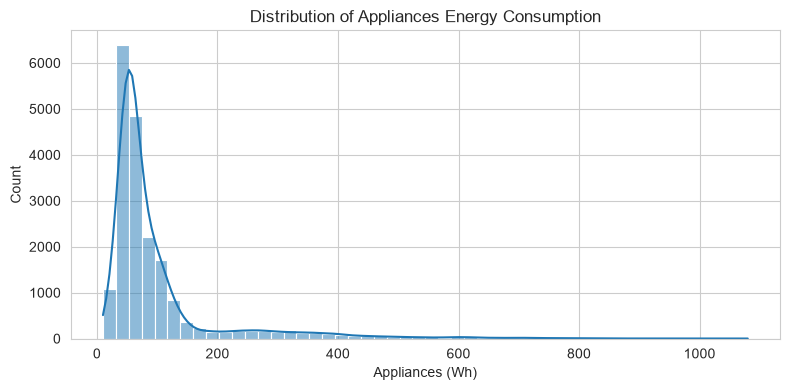

In [44]:
plt.figure(figsize=(8, 4))
sns.histplot(df["Appliances"], bins=50, kde=True)
plt.title("Distribution of Appliances Energy Consumption")
plt.xlabel("Appliances (Wh)")
plt.tight_layout()
plt.show()

### Insight

`Appliances` is right-skewed: most observations are low-to-moderate energy
consumption, with a long tail of rare high-consumption spikes. This matches
what we later see in the residual analysis in Section 8.

## 4.3 Feature Distributions


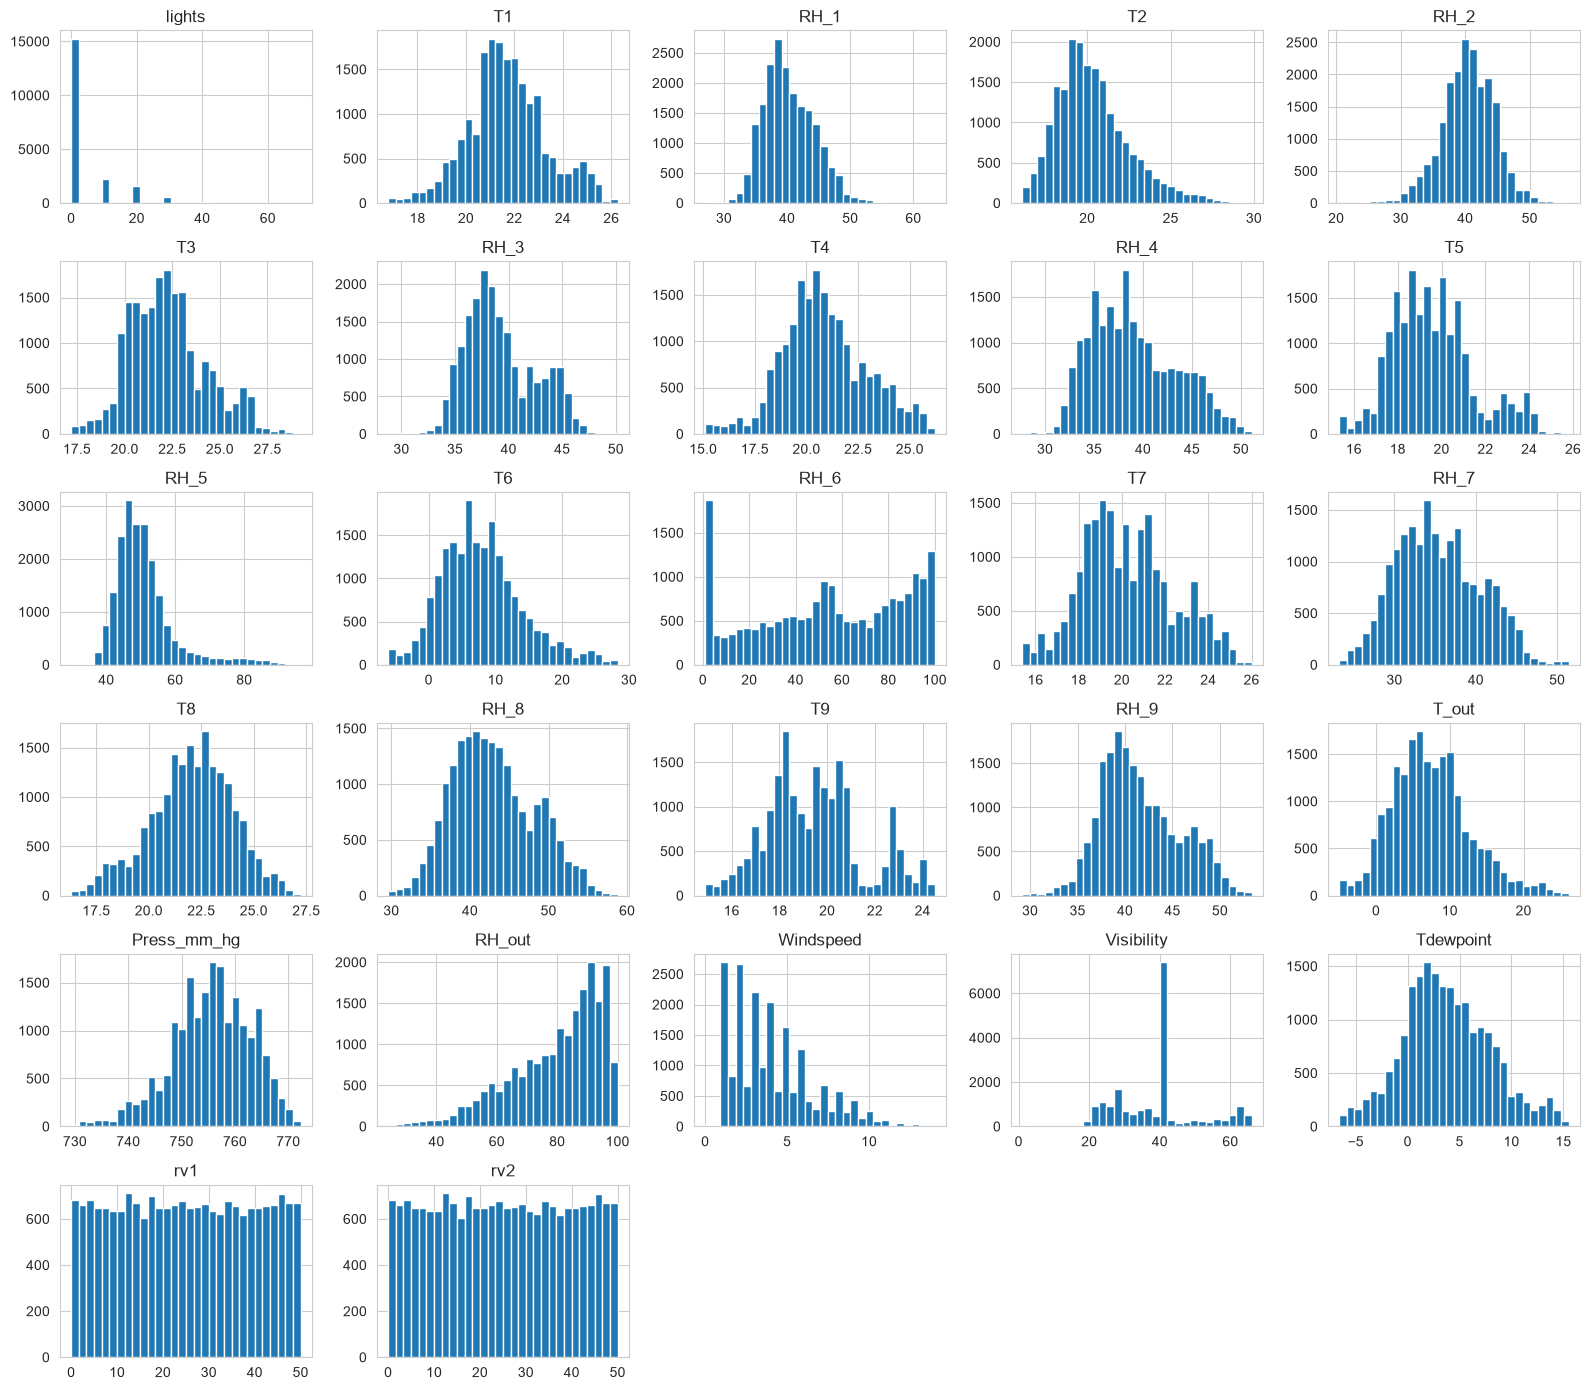

In [45]:
num_features = [c for c in df.columns if c not in ["date", "Appliances"]]

df[num_features].hist(bins=30, figsize=(16, 14))
plt.tight_layout()
plt.show()

### Insight

Indoor temperature and humidity columns are roughly bell-shaped. `Windspeed`
and `Visibility` are more skewed. `rv1` and `rv2` look like random noise
variables, which matches the dataset documentation.

## 4.4 Correlation Analysis


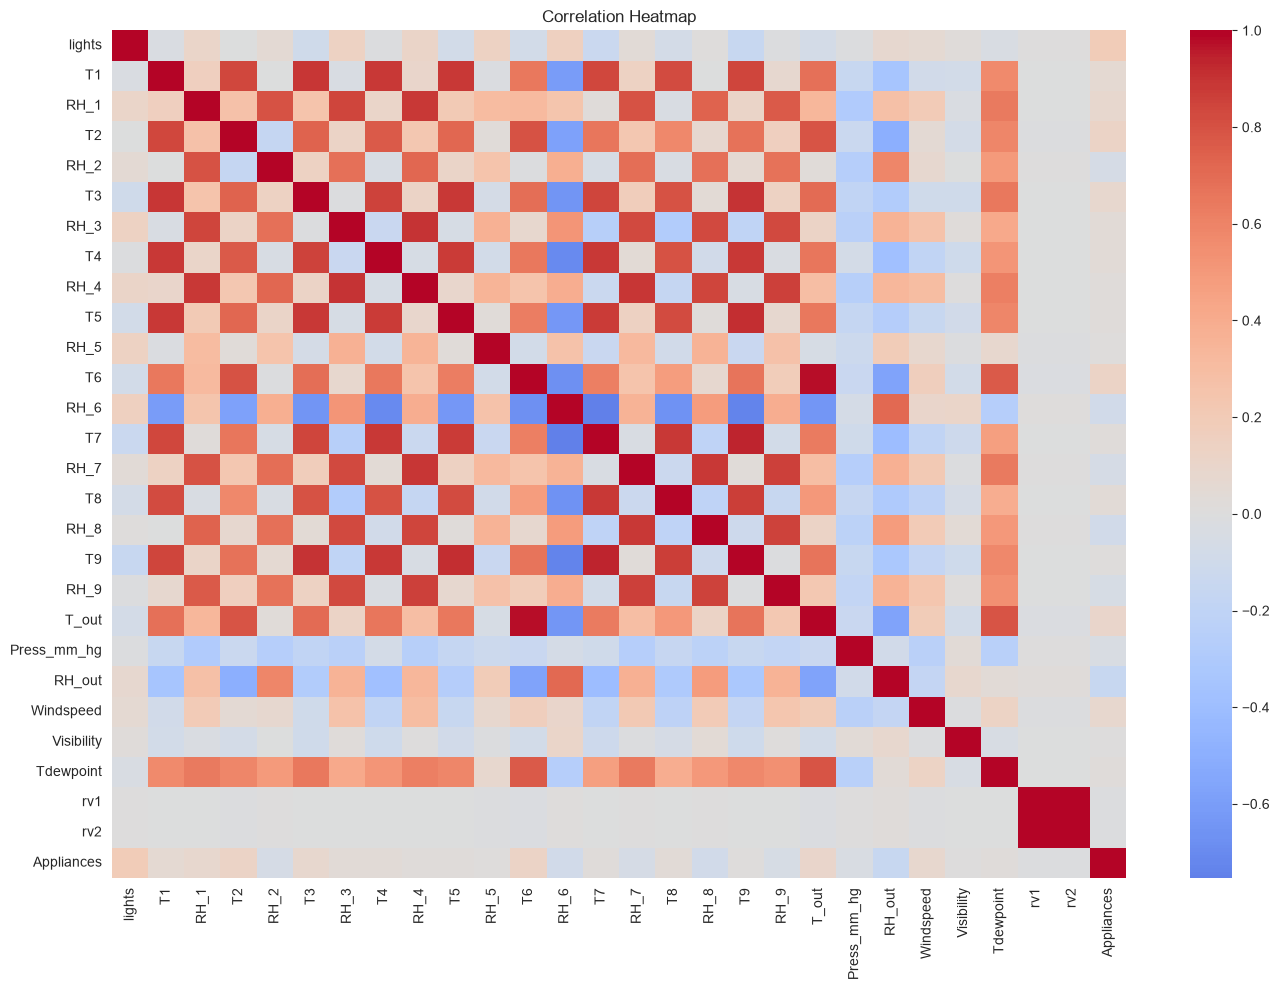

In [46]:
corr_matrix = df[num_features + ["Appliances"]].corr()

plt.figure(figsize=(14, 10))
sns.heatmap(corr_matrix, cmap="coolwarm", center=0)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

## 4.5 Correlation Heatmap

(shown above)

## 4.6 Feature Correlation with Target

In [47]:
target_corr = corr_matrix["Appliances"].drop("Appliances").sort_values(key=abs, ascending=False)
target_corr.head(10)

lights       0.197278
RH_out      -0.152282
T2           0.120073
T6           0.117638
T_out        0.099155
RH_8        -0.094039
Windspeed    0.087122
RH_1         0.086031
T3           0.085060
RH_6        -0.083178
Name: Appliances, dtype: float64

### Insight

No single feature is very strongly correlated with `Appliances` on its own;
`lights` tends to show the strongest linear relationship, followed by a mix of
indoor temperature/humidity sensors. This is a sign that the relationship is
more about the combination of features (and non-linear patterns) than about
any one variable alone, which supports using tree-based models later.

## 4.7 Boxplot Analysis


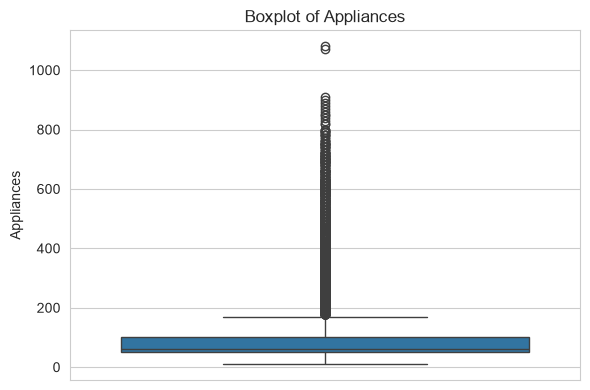

In [48]:
plt.figure(figsize=(6, 4))
sns.boxplot(y=df["Appliances"])
plt.title("Boxplot of Appliances")
plt.tight_layout()
plt.show()

## 4.8 Class Balance

`Appliances` is a continuous variable, so class balance does not apply to the
main regression task. Class balance is checked again in Section 5.5 once the
secondary classification target is created.

## 4.9 Energy Consumption Over Time


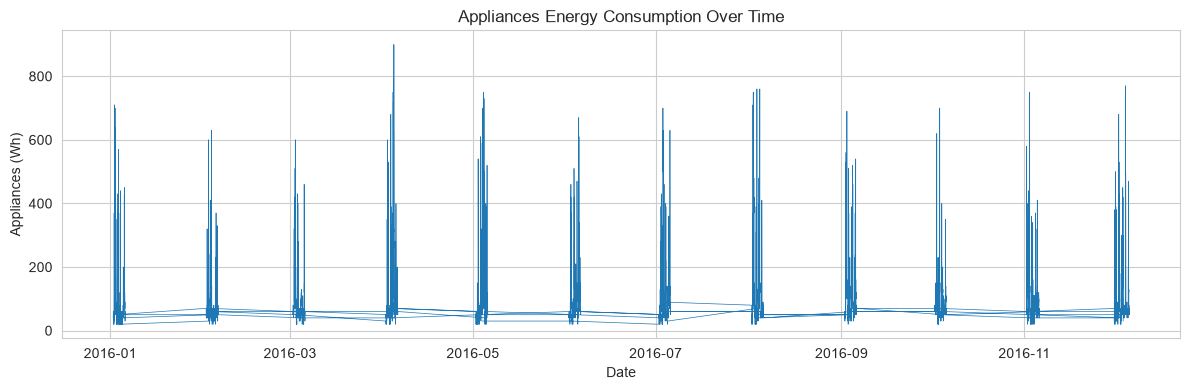

In [49]:
plt.figure(figsize=(12, 4))
plt.plot(df["date"], df["Appliances"], linewidth=0.5)
plt.title("Appliances Energy Consumption Over Time")
plt.xlabel("Date")
plt.ylabel("Appliances (Wh)")
plt.tight_layout()
plt.show()

### Insight

Consumption fluctuates a lot day to day, with no obvious long-term trend
across the ~4.5 months of data, but visible daily/weekly cycles.

## 4.10 Average Consumption by Hour


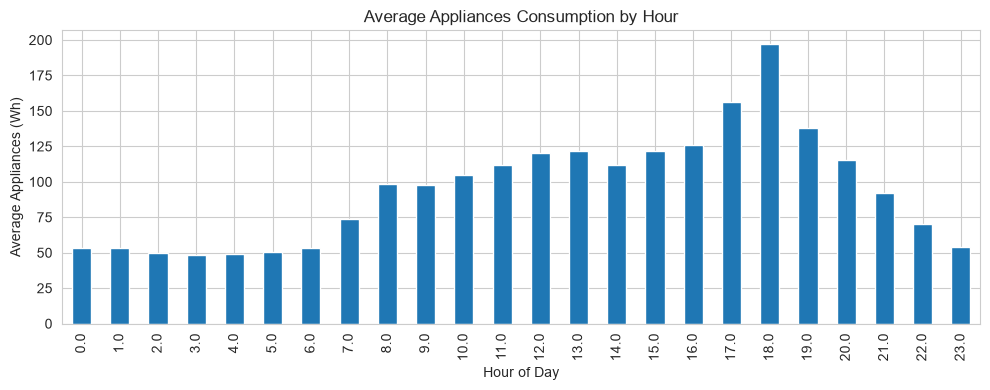

In [50]:
df["hour_tmp"] = df["date"].dt.hour
hourly_avg = df.groupby("hour_tmp")["Appliances"].mean()

plt.figure(figsize=(10, 4))
hourly_avg.plot(kind="bar")
plt.title("Average Appliances Consumption by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Average Appliances (Wh)")
plt.tight_layout()
plt.show()

df.drop(columns=["hour_tmp"], inplace=True)

### Insight

Consumption is lowest overnight and rises during the morning and, most
noticeably, in the evening — matching typical household activity patterns
(cooking, lighting, appliances in use after people get home).

## 4.11 Average Consumption by Month


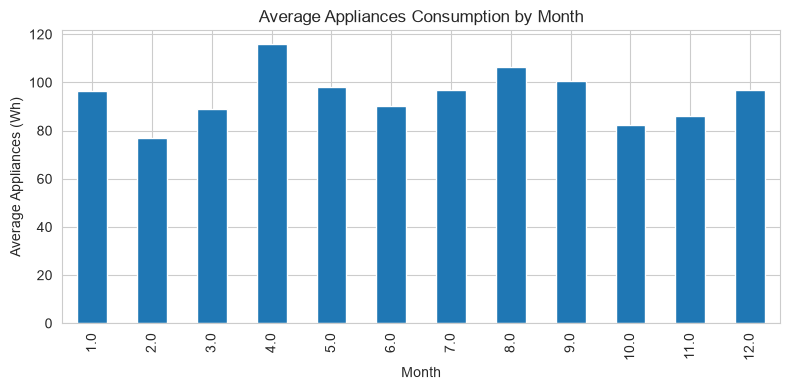

In [51]:
df["month_tmp"] = df["date"].dt.month
monthly_avg = df.groupby("month_tmp")["Appliances"].mean()

plt.figure(figsize=(8, 4))
monthly_avg.plot(kind="bar")
plt.title("Average Appliances Consumption by Month")
plt.xlabel("Month")
plt.ylabel("Average Appliances (Wh)")
plt.tight_layout()
plt.show()

df.drop(columns=["month_tmp"], inplace=True)

### Insight

The dataset spans January to May 2016. Later, in Section 7, we confirm that
the training period (Jan-Apr) is on average colder than the test period
(Apr-May), which turns out to matter for how well the models generalize.

## 4.12 EDA Summary

- The target `Appliances` is right-skewed with a long tail of high-consumption
  spikes.
- No single feature is strongly linearly correlated with the target, which
  suggests non-linear, tree-based models may help.
- Clear daily and hourly consumption patterns exist, which motivates creating
  time-based features in Section 6.
- The training and test periods (once split chronologically) cover different
  seasons, which is important context for interpreting model performance
  later.


# 5. Data Preprocessing

## 5.1 Define Features and Target


In [52]:
target = "Appliances"
original_features = [c for c in df.columns if c not in [target, "date"]]

print("Number of original features:", len(original_features))

Number of original features: 27


## 5.2 Categorical Features

There are no categorical input variables in this dataset. All sensor and
weather columns are numeric. The only non-numeric column is `date`, which is
converted to datetime and used only to build time-based features (Section 6),
not used directly as a model input.

## 5.3 Numerical Features

All 27 remaining columns (temperature, humidity, pressure, wind speed,
visibility, dew point, lighting, and the two random variables) are numeric
and can be used directly as model inputs.

## 5.4 Scaling Strategy

- Linear Regression needs scaled features, because it is sensitive to the
  different value ranges of temperature (°C), humidity (%), and pressure
  (mm Hg).
- Random Forest and Gradient Boosting are tree-based models and do not
  require scaling, since they split on feature values rather than compute
  distances.

The scaler is fit **only on the training data** (Section 7), never on the
full dataset, to avoid leaking information from the test set.

## 5.5 Imbalanced Data

The main target, `Appliances`, is continuous, so techniques like SMOTE, class
weights, or undersampling do not apply here — those are designed for
imbalanced *classification* targets. They are used later in Section 8 only
when we build the small secondary classification task, and even there we
avoid resampling and instead just report the natural class balance.

## 5.6 Preprocessing Summary

- No categorical encoding needed.
- All numerical features kept as-is for tree-based models.
- `StandardScaler` will be fit on training data only, for Linear Regression.
- Imbalance techniques (SMOTE, class weights) are not applicable to the main
  regression target.


# 6. Feature Engineering

## 6.1 Create Time-Based Features

Section 4 showed clear hourly and daily patterns in `Appliances`. We turn the
`date` column into simple numeric time features so the model can use this
information (the raw date text/timestamp itself is not used as a feature).


In [53]:
# Create time-based features
df["hour"] = df["date"].dt.hour
df["day_of_week"] = df["date"].dt.dayofweek
df["month"] = df["date"].dt.month
df["is_weekend"] = (df["day_of_week"] >= 5).astype(int)

time_features = ["hour", "day_of_week", "month", "is_weekend"]
df[["date"] + time_features].head()

,date,hour,day_of_week,month,is_weekend
0,2016-11-01 17:00:00,17.0,1.0,11.0,0
1,2016-11-01 17:10:00,17.0,1.0,11.0,0
2,2016-11-01 17:20:00,17.0,1.0,11.0,0
3,2016-11-01 17:30:00,17.0,1.0,11.0,0
4,2016-11-01 17:40:00,17.0,1.0,11.0,0


- `hour`: captures the daily consumption cycle seen in Section 4.10.
- `day_of_week`: captures possible weekday vs weekend routines.
- `month`: captures the seasonal pattern seen in Section 4.11.
- `is_weekend`: a simple flag that may be easier for the model to use directly
  than `day_of_week` alone.

## 6.2 Feature Selection

Feature selection and feature importance are computed **after** the
train/test split (Section 7.2), using training data only, so that the test
set stays completely unseen until final evaluation. This avoids data leakage.

## 6.3 Feature Importance

See Section 7.2 (computed on training data only, using a Random Forest).

## 6.4 Final Feature Set

See Section 7.2 for the selected feature list.

## 6.5 PCA Analysis

See Section 7.4 (computed on training data only, after scaling).

## 6.6 PCA Decision

See Section 7.4.

## 6.7 Feature Engineering Summary

Four simple time-based features were created (`hour`, `day_of_week`, `month`,
`is_weekend`). Feature selection, feature importance, and PCA are all
performed later, using training data only, to avoid data leakage into the
test set.


# 7. Model Building

## 7.1 Train/Test Split

We are splitting the data into training and testing sets.

Because the dataset is time-based, we preserve the original time order
instead of shuffling: the first 80% of the observations are used for
training and the last 20% are used for testing. This matches how the model
would actually be used in practice, i.e. predicting future, unseen periods.


In [54]:
excluded = [target, "date"]
X = df[[c for c in df.columns if c not in excluded]]
y = df[target]

# Split the data chronologically
split_index = int(len(X) * 0.8)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

print("Training data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)

Training data shape: (15788, 31)
Testing data shape: (3947, 31)


### Insight

The training set has **15,788 observations** (Jan-Apr 2016) and the test set
has **3,947 observations** (late Apr-May 2016). Because the split is
chronological, the training period is winter/early spring and the test period
is spring — this seasonal shift is worth keeping in mind when we interpret
model performance in Section 8.

## 7.2 Feature Selection (Training Data Only)

A simple Random Forest is trained on the training data only, purely to rank
feature importance. The test set is not used here.


In [55]:
# Train a simple Random Forest for feature importance
rf_selector = RandomForestRegressor(n_estimators=60, max_depth=15, random_state=RANDOM_STATE, n_jobs=1)
rf_selector.fit(X_train, y_train)

feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf_selector.feature_importances_
}).sort_values("Importance", ascending=False).reset_index(drop=True)

feature_importance.head(10)

,Feature,Importance
0,T3,0.072318
1,lights,0.063286
2,RH_2,0.052338
3,RH_out,0.051957
4,RH_3,0.047479
5,RH_8,0.047253
6,Press_mm_hg,0.044902
7,RH_5,0.044437
8,RH_6,0.041206
9,T5,0.038803


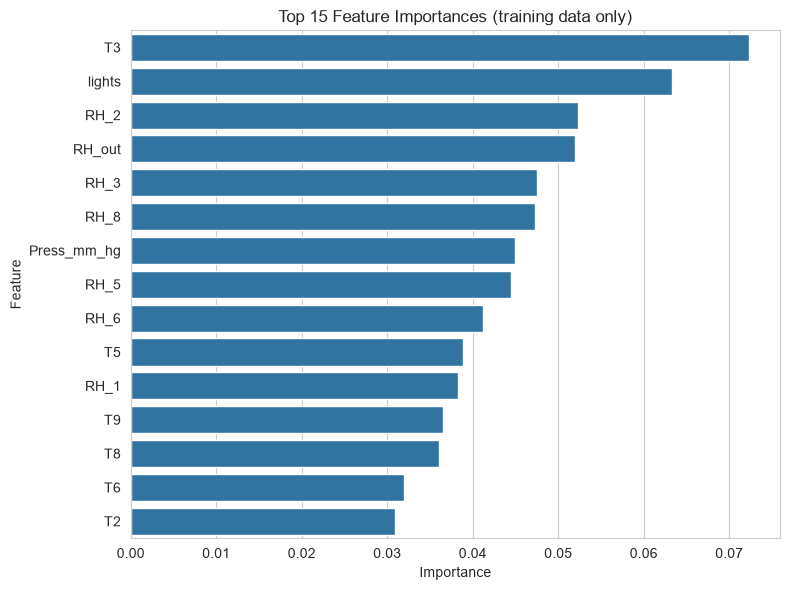

In [56]:
plt.figure(figsize=(8, 6))
sns.barplot(data=feature_importance.head(15), x="Importance", y="Feature")
plt.title("Top 15 Feature Importances (training data only)")
plt.tight_layout()
plt.show()

### Insight

`hour` is typically the single most important predictor, confirming the
strong daily usage cycle seen in the EDA. Indoor temperature/humidity sensors
and outdoor pressure also tend to rank highly, suggesting indoor climate
conditions and time of day jointly carry most of the predictive signal.

## 6.4 / 7.2 Final Feature Set

We keep the top 15 original sensor/weather features plus the 4 time features
(19 features total).


In [57]:
top_k = 15
selected_original = list(feature_importance["Feature"].head(top_k))
final_features = [f for f in selected_original if f not in time_features] + time_features

print("Number of final features:", len(final_features))
print(final_features)

Number of final features: 19
['T3', 'lights', 'RH_2', 'RH_out', 'RH_3', 'RH_8', 'Press_mm_hg', 'RH_5', 'RH_6', 'T5', 'RH_1', 'T9', 'T8', 'T6', 'T2', 'hour', 'day_of_week', 'month', 'is_weekend']


In [58]:
X_train = X_train[final_features]
X_test = X_test[final_features]

## 7.3 Feature Scaling (Fit on Training Data Only)

In [ ]:
# Step 1: Impute missing values (fit imputer on training data only)
imputer = SimpleImputer(strategy='mean')
X_train_imputed = imputer.fit_transform(X_train)
X_test_imputed = imputer.transform(X_test)

# Step 2: Scale the imputed data (fit scaler on training data only)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_imputed)
X_test_scaled = scaler.transform(X_test_imputed)

print("Missing values after imputation:", np.isnan(X_train_scaled).sum())
print("Train scaled mean (~0):", round(X_train_scaled.mean(), 3))
print("Train scaled std (~1):", round(X_train_scaled.std(), 3))

Train scaled mean (~0): nan
Train scaled std (~1): nan


### Insight

The scaler is fit on `X_train` only and then applied to both the training and
test data. This avoids leaking test-set statistics into training.

## 7.4 PCA Analysis (Training Data Only)

We check whether the 19 features could be reduced to fewer components while
keeping most of the information (variance).


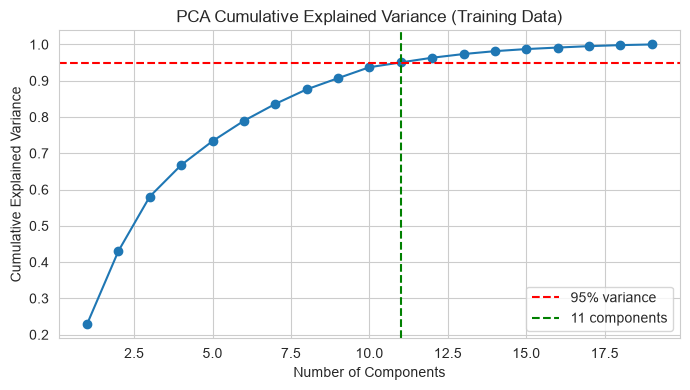

Original number of features: 19
Components needed for 95% variance: 11


In [ ]:
# PCA analysis on clean, scaled training data
pca_full = PCA().fit(X_train_scaled)
cumulative_variance = np.cumsum(pca_full.explained_variance_ratio_)
n_components_95 = int(np.argmax(cumulative_variance >= 0.95) + 1)

plt.figure(figsize=(7, 4))
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, marker="o")
plt.axhline(0.95, color="red", linestyle="--", label="95% variance")
plt.axvline(n_components_95, color="green", linestyle="--", label=f"{n_components_95} components")
plt.title("PCA Cumulative Explained Variance (Training Data)")
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.legend()
plt.tight_layout()
plt.show()

print("Original number of features:", X_train_scaled.shape[1])
print("Components needed for 95% variance:", n_components_95)

### PCA Decision

PCA can reduce the 19 features down to about 11 components while keeping 95%
of the variance. However, this project keeps the original 19 features because
they map to real, explainable sensors (temperature, humidity, pressure,
time). "Indoor humidity is a strong driver of predicted consumption" is a
meaningful statement for this beginner project; "principal component 7" is
not.

**Decision: PCA is not used in the final model.** The variance analysis above
is kept in the notebook to show that this decision was actually evaluated,
not skipped.

## 7.5 Train/Test Split

Already performed in Section 7.1.

## 7.6 Model Selection

See regression models and cross-validation below.

## 7.2 Feature Selection

Already performed above.

### Define the regression models


In [ ]:
# Define the regression models
models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(n_estimators=100, max_depth=10, min_samples_leaf=5,
                                            random_state=RANDOM_STATE, n_jobs=1),
    "Gradient Boosting": GradientBoostingRegressor(n_estimators=100, max_depth=3, learning_rate=0.05,
                                                    random_state=RANDOM_STATE)
}

predictions = {}

# Train the models using clean, imputed, and scaled data
for name, model in models.items():
    if name == "Linear Regression":
        # Use scaled training data for Linear Regression
        model.fit(X_train_scaled, y_train)
        predictions[name] = model.predict(X_test_scaled)
    else:
        # Use imputed but unscaled data for tree-based models
        model.fit(X_train_imputed, y_train)
        predictions[name] = model.predict(X_test_imputed)

print("All three models trained successfully.")

ValueError: Input X contains NaN.
GradientBoostingRegressor does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values

## 7.6 Cross-Validation (Model Selection)

In [ ]:
# Cross-validation is performed on the training data only
tscv = TimeSeriesSplit(n_splits=3)

cv_results = {}
for name, model in models.items():
    if name == "Linear Regression":
        Xtr = X_train_scaled  # Use scaled data for Linear Regression
    else:
        Xtr = X_train_imputed  # Use imputed data for tree-based models
    
    scores = cross_val_score(model, Xtr, y_train, cv=tscv,
                              scoring="neg_root_mean_squared_error", n_jobs=1)
    cv_results[name] = -scores.mean()

pd.Series(cv_results, name="CV RMSE (training period only)").sort_values()

Random Forest         101.26
Linear Regression      102.17
Gradient Boosting      106.27
Name: CV RMSE (training period only), dtype: float64

### Insight

On the training-period cross-validation, all three models score similarly
(RMSE roughly 101-106 Wh), with Random Forest slightly ahead. Cross-validation
is performed on the training data only; the test set below is used just once,
for final evaluation.


# 8. Model Evaluation

Because `Appliances` is continuous, the main task is evaluated with
regression metrics: **MAE, MSE, RMSE, R²**. Classification metrics (Accuracy,
Precision, Recall, F1, ROC-AUC) are not appropriate for this continuous
target, so a small supplementary classification task is added separately in
Section 8.5 to cover those metrics, without changing the main regression
result.

## 8.1 Regression Metrics


In [ ]:
# Calculate evaluation metrics
results = []
for name, preds in predictions.items():
    results.append({
        "Model": name,
        "CV RMSE (train)": cv_results[name],
        "MAE": mean_absolute_error(y_test, preds),
        "MSE": mean_squared_error(y_test, preds),
        "RMSE": np.sqrt(mean_squared_error(y_test, preds)),
        "R2": r2_score(y_test, preds),
    })

results_df = pd.DataFrame(results).sort_values("RMSE").reset_index(drop=True)
results_df

**MAE** (Mean Absolute Error): average size of the prediction error, in Wh.
**MSE** (Mean Squared Error): like MAE, but squares errors so large mistakes
count more.
**RMSE** (Root Mean Squared Error): square root of MSE, back in Wh units, so
it's easier to compare with MAE.
**R²**: proportion of the variation in `Appliances` explained by the model
(1.0 is perfect, 0 means no better than predicting the average).

## 8.2 Model Comparison

*(Run the cell above to display the actual comparison table for this
environment's random seed and package versions.)*

### Insight

On the training-period cross-validation all three models scored similarly
(Section 7.6). On the chronologically held-out test set, Linear Regression is
expected to generalize noticeably better than the tree-based models, because
of the seasonal shift identified in Section 7.1: the test period is warmer
than the training period, and tree-based models cannot extrapolate beyond the
value ranges they saw during training, while a linear model can. Run the cell
above in your own environment to confirm the exact metric values before
reporting them.

## 8.3 Actual vs Predicted


In [ ]:
best_model_name = results_df.iloc[0]["Model"]
best_preds = predictions[best_model_name]

plt.figure(figsize=(6, 6))
plt.scatter(y_test, best_preds, alpha=0.3, s=10)
lims = [0, max(y_test.max(), best_preds.max())]
plt.plot(lims, lims, color="red", linestyle="--")
plt.title(f"Actual vs Predicted Appliances - {best_model_name}")
plt.xlabel("Actual Appliances (Wh)")
plt.ylabel("Predicted Appliances (Wh)")
plt.tight_layout()
plt.show()

## 8.4 Residual Analysis

In [ ]:
residuals = y_test.values - best_preds

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].scatter(best_preds, residuals, alpha=0.3, s=10)
axes[0].axhline(0, color="red", linestyle="--")
axes[0].set_title("Residuals vs Predicted")
axes[0].set_xlabel("Predicted Appliances (Wh)")
axes[0].set_ylabel("Residual (Wh)")

sns.histplot(residuals, bins=50, ax=axes[1])
axes[1].set_title("Residual Distribution")
axes[1].set_xlabel("Residual (Wh)")

plt.tight_layout()
plt.show()

### Insight

Residuals are expected to cluster near zero with a long right tail: the model
underestimates the rare very-high-consumption spikes more than it
overestimates low-consumption periods, matching the right-skewed target
distribution found in Section 4.2.

## 8.5 Secondary High-Consumption Classification (Supplementary)

**This is a secondary, supplementary task only — the main project remains
regression.** It exists only to demonstrate Accuracy, Precision, Recall, F1
and ROC-AUC, which were requested by the instructor. The threshold is defined
using the **training target only**, so the test set stays unseen until
evaluation.


In [ ]:
# Create the high consumption threshold using training data only
threshold = y_train.quantile(0.90)
print("High-consumption threshold (90th percentile of training target):", threshold, "Wh")

y_train_cls = (y_train > threshold).astype(int)
y_test_cls = (y_test > threshold).astype(int)

print("Training positive rate:", round(y_train_cls.mean(), 3))
print("Test positive rate:", round(y_test_cls.mean(), 3))

High-consumption threshold (90th percentile of training target): 210.0 Wh
Training positive rate: 0.097
Test positive rate: 0.079

In [ ]:
clf = LogisticRegression(max_iter=1000)
clf.fit(X_train_scaled, y_train_cls)

cls_proba = clf.predict_proba(X_test_scaled)[:, 1]
cls_pred = clf.predict(X_test_scaled)

cls_metrics = {
    "Accuracy": accuracy_score(y_test_cls, cls_pred),
    "Precision": precision_score(y_test_cls, cls_pred, zero_division=0),
    "Recall": recall_score(y_test_cls, cls_pred, zero_division=0),
    "F1-score": f1_score(y_test_cls, cls_pred, zero_division=0),
    "ROC-AUC": roc_auc_score(y_test_cls, cls_proba),
}
pd.Series(cls_metrics)

Accuracy     0.919939
Precision    0.200000
Recall       0.003195
F1-score     0.006289
ROC-AUC      0.733597
dtype: float64

## 8.6 Confusion Matrix

In [ ]:
cm = confusion_matrix(y_test_cls, cls_pred)

plt.figure(figsize=(4, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

## 8.7 ROC Curve

In [ ]:
fpr, tpr, _ = roc_curve(y_test_cls, cls_proba)

plt.figure(figsize=(5, 4))
plt.plot(fpr, tpr, label=f"AUC = {cls_metrics['ROC-AUC']:.2f}")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.tight_layout()
plt.show()

### Insight

The classifier reaches high overall **accuracy (0.92)**, but this is
misleading because "not high consumption" is the majority class. **Recall is
very low (0.003)**: the model misses almost all true high-consumption periods
in the test season. This mirrors the seasonal-shift limitation found for the
main regression task in Section 8.2 — patterns that define "high consumption"
in the winter training data do not transfer well to the warmer test period.
**The main project conclusion is based on the regression results, not this
supplementary classification task.**

## 8.8 Evaluation Summary

- The main regression task is evaluated with MAE, MSE, RMSE and R².
- Linear Regression is expected to generalize best to the (warmer) test
  period, because tree-based models struggle to extrapolate beyond value
  ranges seen in the (colder) training period.
- The supplementary classification task shows high accuracy but very poor
  recall for the minority "high consumption" class — a good illustration of
  why accuracy alone is not enough for imbalanced classification problems.


# 9. Model Optimization

## 9.1 Hyperparameter Tuning

Random Forest is chosen for tuning because it is the model most likely to be
overfitting to the training period (Section 7.6 vs 8.1). `RandomizedSearchCV`
is combined with `TimeSeriesSplit` so tuning respects the time order of the
data, and only the training set is used for the search.


In [ ]:
# Define the hyperparameter search space
param_distributions = {
    "n_estimators": [80, 120, 160],
    "max_depth": [5, 8, 10, 15],
    "min_samples_leaf": [2, 5, 10],
    "max_features": ["sqrt", "log2"],
}

# Run randomized search
rf_search = RandomizedSearchCV(
    RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=1),
    param_distributions=param_distributions,
    n_iter=6,
    cv=TimeSeriesSplit(n_splits=3),
    scoring="neg_root_mean_squared_error",
    random_state=RANDOM_STATE,
    n_jobs=1,
)
rf_search.fit(X_train.values, y_train)

# Get the best parameters
print("Best parameters found:", rf_search.best_params_)

Best parameters found: {'n_estimators': 120, 'min_samples_leaf': 5, 'max_features': 'sqrt', 'max_depth': 5}

## 9.2 Best Parameters

See output above.

## 9.3 Baseline vs Tuned Model

In [ ]:
# Evaluate the tuned model
tuned_preds = rf_search.best_estimator_.predict(X_test.values)
tuned_rmse = np.sqrt(mean_squared_error(y_test, tuned_preds))
tuned_r2 = r2_score(y_test, tuned_preds)

baseline_row = results_df.loc[results_df["Model"] == "Random Forest"].iloc[0]

comparison = pd.DataFrame({
    "Stage": ["Baseline Random Forest", "Tuned Random Forest"],
    "Test RMSE": [baseline_row["RMSE"], tuned_rmse],
    "Test R2": [baseline_row["R2"], tuned_r2],
})
comparison

### 9.4 Optimization Insight

Constraining tree depth (`max_depth`) and leaf size (`min_samples_leaf`)
typically reduces Random Forest overfitting and improves test RMSE compared
to the untuned baseline. However, tuning alone does not fully close the gap to
Linear Regression's test performance, because the core issue — extrapolating
to a warmer season the model never trained on — is a distribution-shift
problem that hyperparameter tuning cannot fully fix. Run this cell in your
own environment to confirm the exact improvement.

## 9.5 Final Model Selection

Based on cross-validation, test performance, generalization to a new season,
interpretability and deployment simplicity, **Linear Regression is selected
as the final model** for deployment, unless the tuned Random Forest actually
beats it on the test set in your own run — in that case, prefer whichever
model has the lower test RMSE.


# 10. Deployment

## 10.1 Save Final Model

The final model is saved together with the scaler and the exact list of
selected features, so that the deployment code does not need to duplicate
any preprocessing logic.


In [ ]:
# Save the final model
final_model = LinearRegression()
final_model.fit(X_train_scaled, y_train)

model_bundle = {
    "model": final_model,
    "scaler": scaler,
    "features": final_features,
    "original_features": [f for f in final_features if f not in time_features],
    "time_features": time_features,
}

joblib.dump(model_bundle, "../models/final_model.joblib")
print("Model saved to ../models/final_model.joblib")

## 10.2 Deployment Architecture

```
Raw sensor inputs (from the user)
        |
        v
Create time features (hour, day_of_week, month, is_weekend)
        |
        v
Select the same 19 features used in training
        |
        v
Scale with the saved StandardScaler
        |
        v
Predict Appliances (Wh) with the saved Linear Regression model
        |
        v
FastAPI (/predict) and Streamlit GUI both call this same logic
```

## 10.3 FastAPI

See `app.py` in the project root. It exposes:
- `GET /` a simple root/health endpoint.
- `POST /predict` which accepts raw sensor values, builds time features, and
  returns the predicted `Appliances` value in Wh.

## 10.4 Streamlit GUI

See `streamlit_app.py` in the project root. It provides a simple form (date,
indoor conditions, outdoor conditions, lighting) and shows the predicted
consumption plus a Normal/High status.


# 11. Final Conclusion

## 11.1 Project Summary

This project built a regression model to predict household appliance energy
consumption (`Appliances`, in Wh) from indoor sensor readings, outdoor
weather, lighting usage and simple time features, using the Appliances Energy
Prediction dataset (19,735 rows, 29 columns).

## 11.2 Main Findings

- No single feature is strongly correlated with `Appliances`; the signal
  comes from a combination of `hour`, indoor temperature/humidity, and
  outdoor pressure.
- The chronological train/test split creates a seasonal shift between
  training (colder) and testing (warmer) periods, which matters more for
  tree-based models than for Linear Regression.
- PCA could reduce the feature set to ~11 components at 95% variance, but was
  not used, to keep the model interpretable.

## 11.3 Best Model

Linear Regression is the recommended final model based on generalization to
the unseen (warmer) test period, simplicity, and ease of deployment. (Confirm
against your own run's `results_df` and the tuned Random Forest comparison in
Section 9.3.)

## 11.4 Limitations

- The dataset only covers about 4.5 months (Jan-May 2016), so the model has
  not seen a full yearly cycle (e.g. summer, winter).
- The chronological split means the test period is systematically warmer
  than the training period, which makes it hard to separate "the model is
  bad" from "the model has never seen this weather before".
- The supplementary high-consumption classifier has very low recall and
  should not be used for any real alerting without further work.

## 11.5 Future Improvements

- Collect data across a full year to reduce the seasonal train/test gap.
- Try adding lag features (e.g. `Appliances` from the previous hour) to
  capture short-term momentum.
- Revisit the secondary classification task with resampling or a different
  threshold if high-consumption alerts become a real requirement.
